#**ANALISI DEL SENTIMENT SUL BITCOIN TRAMITE TWEET /<br>_SENTIMENT ANALYSIS ON BITCOIN THROUGH TWEETS_**

In questo notebook viene condotta un’analisi del sentiment sul Bitcoin, con l’obiettivo di comprendere l’opinione e il livello di coinvolgimento degli utenti sui social media. I dati analizzati sono costituiti da tweet in varie lingue raccolti su larga scala. L’analisi consente di misurare il sentiment pubblico nei confronti della criptovaluta, valutare i livelli di coinvolgimento e indagare eventuali correlazioni tra sentiment espresso e andamento del prezzo del Bitcoin.

_In this notebook, a sentiment analysis on Bitcoin is conducted to understand public opinion and user engagement on social media. The data analyzed consist of tweets in various languages collected at scale. The analysis aims to measure public sentiment toward the cryptocurrency, evaluate engagement levels, and investigate potential correlations between expressed sentiment and Bitcoin price trends._

##**1. Preparazione del notebook / _Notebook preparation_**

In [ ]:
# Montaggio Drive per caricamento dataset con sentiment
# Mount Drive to upload dataset with sentiment
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importazione risorse necessarie
# Import required resources
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import math
from tqdm.auto import tqdm # Per controllo avanzamento processo - For process progress control
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.window import Window

In [ ]:
# Configurazione ambiente Spark
# Spark environment configuration
spark = SparkSession.builder.appName("BitcoinSentimentAnalysis").getOrCreate()

# Caricamento dataset in DF Spark
# Load dataset in Spark DF
URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/bitcoin_tweets.csv"
LOCAL_PATH = "/content/bitcoin_tweets.csv"

! wget -O {LOCAL_PATH} "{URL}"

df_spark = spark.read.csv(LOCAL_PATH, header=True, inferSchema=True, multiLine=True, escape='"')

# Ispezione iniziale del df
# Initial inspection of df
print("Records:", df_spark.count())
df_spark.printSchema()
df_spark.show(15, False)

--2026-03-02 12:55:21--  https://proai-datasets.s3.eu-west-3.amazonaws.com/bitcoin_tweets.csv
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.206.133, 16.12.19.18
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.206.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24708828 (24M) [text/csv]
Saving to: ‘/content/bitcoin_tweets.csv’

/content/bitcoin_tw 100%[===================>]  23.56M  11.4MB/s    in 2.1s    

2026-03-02 12:55:23 (11.4 MB/s) - ‘/content/bitcoin_tweets.csv’ saved [24708828/24708828]

Records: 100001
root
 |-- id: double (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = 

In [ ]:
# Preparazione del df:
# Df preparation:

# Pulizia del testo
# Text cleaning
df_spark = df_spark.withColumn("text_clean", trim(
    regexp_replace(
        regexp_replace(
          regexp_replace(
              regexp_replace(col("text"), r"https\S+", ""), # Rimozione URL - URL remove
          r"@\w+", ""), # Rimozione @menzioni - @mention remove
        r"[^\p{L}\p{N}\s]", ""), # Rimozione caratteri speciali (mantendendo lettere accentate e non latine essendo dataset multilingua) \
                                  # Special characters remove (mantaining accented and non-latin letters, as the dataset is multilingual)
    r"\s+", " "))) # Rimozione spazi multipli - Extra spaces remove

# Rimozione tweet troppo corti (< 5 caratteri)
# Remove tweets too short (< 5 chars)
df_spark = df_spark.filter(length(col("text_clean")) >= 5)

# Rimozione colonne non necessarie e creazione colonna "date"
# Removing unnecessary columns and create "date" column
df_spark = df_spark.drop("user", "fullname", "url")

# Conversione colonna "timestamp" in formato timestamp e creazione colonna "date"
# Convert "timestamp" column in timestamp type and create "date" column
df_spark = df_spark.withColumn("timestamp", to_timestamp(col("timestamp"))) \
    .withColumn("date", to_date(col("timestamp")))

# Conversione "id" in stringa per evitare perdita di precisione
# Convert "id" to string to avoid precision loss
df_spark = df_spark.withColumn("id", col("id").cast("string"))

df_spark.printSchema()
df_spark.show(15, False)

root
 |-- id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = true)
 |-- text_clean: string (nullable = true)
 |-- date: date (nullable = true)

+----------------------+-------------------+-------+-----+--------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|id                    |timestamp          |replies|likes|retw

In [ ]:
# Controllo di eventuali valori mancanti
# Checking for missing values
df_spark.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_spark.columns]).show()

+---+---------+-------+-----+--------+----+----------+----+
| id|timestamp|replies|likes|retweets|text|text_clean|date|
+---+---------+-------+-----+--------+----+----------+----+
|  0|        0|      0|    0|       0|   0|         0|   0|
+---+---------+-------+-----+--------+----+----------+----+



In [ ]:
# Controllo finale di eventuali record con stringhe vuote in "text_clean"
# Final check for records with empty strings in "text_clean"
df_spark.filter(col("text_clean") == "").count()

0

In [ ]:
print("Record dopo pulizia - Records after cleaning:", df_spark.count())

Record dopo pulizia - Records after cleaning: 97950


##**2. Analisi del Sentiment / _Sentiment Analysis_**

**NOTA:** Le seguenti celle relative alla sentiment analysis sono state messe come #Commento per evitare la riesecuzione in questo ambiente. L'elaborazione è stata eseguita su Kaggle utilizzando la GPU maggiormente disponibile in quell'ambiente. Le celle vengono mantenute nel notebook per documentare il processo metodologico e mostrare gli output ottenuti dall'esecusione su Kaggle.

_**NOTE:** The following cells related to sentiment analysis have been #Commented out to prevent re-execution in thin evironment. The processing was carried out on Kaggle using the most suitable GPU available in that environment. The cells are retained in the notebook to document the methodological process and to dispaly the outputs obtained from the execution on Kaggle._

In [ ]:
# Installazione librerie per sentiment analysis con HuggingFace
# Install required libraries for HuggingFace sentiment analysis
#! pip install -U transformers accelerate

In [ ]:
# Estrazione e conversione in pandas delle sole colonne necessarie per la sentiment analysis
# Extraction and cenversion in pandas of only columns necessary for sentiment analysis
#df_sentiment = df_spark.select("id", "text_clean").toPandas()

#print("No Records:", len(df_sentiment))
#df_sentiment.head(10)

No Records: 97950


,id,text_clean
0,1.1329770553003008E18,È appena uscito un nuovo video LES CRYPTOMONNA...
1,1.13297707340273664E18,Cardano Digitize Currencies EOS 6500 ROI ATamp...
2,1.13297702389313958E18,Another Test tweet that wasnt caught in the st...
3,1.13297708908955635E18,Current Crypto Prices BTC 872199 USD ETH 26662...
4,1.13297709234019123E18,Spiv Nosar Baz BITCOIN Is An Asset amp NOT A C...
5,1.13297710030931955E18,btc inceldiği yerden kopsun bakalım 1700 ye ka...
6,1.13297710163889766E18,We have been building on the real bitcoin SV W...
7,1.1329771088363232E18,como investidor vc é um ótimo dev Sorte q eu c...
8,1.13297713185035059E18,ブラジルはまぁ置いといてもドイツは存在感出してくるのかなロシアもマイニングなどで元気になるか...
9,1.13297713271456154E18,CHANGE IS COMINGGET READY Boom Another CB Jab ...


In [ ]:
# Inizializzazione pipeline HuggingFace
# Initialize HuggingFace pipeline
#model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

#sentiment_pipeline = pipeline("sentiment-analysis", model=model_name, device=0)

#model_name

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

'cardiffnlp/twitter-xlm-roberta-base-sentiment'

In [ ]:
# Divisione in batch con pipeline diretta in GPU
# Batch division with direct GPU pipeline
#batch_size = 64

#texts = df_sentiment["text_clean"].tolist()

#results = []

#num_batches = math.ceil(len(texts) / batch_size)

#for i in tqdm(range(num_batches)):
  #start = i * batch_size
  #end = start + batch_size
  #batch_texts = texts[start:end]
  #batch_results = sentiment_pipeline(batch_texts)
  #results.extend(batch_results)

  0%|          | 0/1531 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Creazione colonne con output del modello
# Create columns from model output
#df_sentiment["sentiment"] = [result["label"] for result in results]

#df_sentiment

,id,text_clean,sentiment
0,1.1329770553003008E18,È appena uscito un nuovo video LES CRYPTOMONNA...,neutral
1,1.13297707340273664E18,Cardano Digitize Currencies EOS 6500 ROI ATamp...,neutral
2,1.13297702389313958E18,Another Test tweet that wasnt caught in the st...,negative
3,1.13297708908955635E18,Current Crypto Prices BTC 872199 USD ETH 26662...,neutral
4,1.13297709234019123E18,Spiv Nosar Baz BITCOIN Is An Asset amp NOT A C...,neutral
...,...,...,...
97945,1.12720999027465421E18,facts bitcoin,neutral
97946,1.1272101524096736E18,BitcoinLend Airdropping 1000000 BLEND 1000000 ...,neutral
97947,1.12721023887519322E18,inzura tokensale Now is good time to get rich ...,positive
97948,1.12721030988482957E18,XRP Bitcoin and other coins to be made availab...,neutral


In [ ]:
# Salvataggio in CSV del df_sentiment generato in Kaggle per successivo utilizzo in questo ambiente Colab
# Saving df_sentiment to CSV generated in Kaggle for subsequent use in this Colab evironment
#df_sentiment.to_csv("/kaggle/working/btc_tweet_sentiment.csv", index=False)
#print("File salvato")

File salvato


**NOTA:** Da questo punto in avanti il processo riprende e viene eseguito interamente in questo ambiente.

_**NOTE:** From this point onward, the process resumes and is carried out entirely in this environment._

In [ ]:
# Caricamento df_sentiment da file CSV
# Load df_sentiment from CSV file
FILE_SENTIMENT_PATH = "/content/drive/MyDrive/Colab Notebooks/11. Big Data/Progetto_ANALISI DEL CONSENSO SUL BITCOIN/btc_tweet_sentiment.csv"

df_sentiment = spark.read.csv(FILE_SENTIMENT_PATH, header=True, multiLine=True, escape='"')

print("Records:", df_sentiment.count())
df_sentiment.printSchema()
df_sentiment.show()

Records: 97950
root
 |-- id: string (nullable = true)
 |-- text_clean: string (nullable = true)
 |-- sentiment: string (nullable = true)

+--------------------+-------------------------------------+---------+
|                  id|                           text_clean|sentiment|
+--------------------+-------------------------------------+---------+
|1.132977055300300...|                 È appena uscito u...|  neutral|
|1.132977073402736...|                 Cardano Digitize ...|  neutral|
|1.132977023893139...|                 Another Test twee...| negative|
|1.132977089089556...|                 Current Crypto Pr...|  neutral|
|1.132977092340191...|                 Spiv Nosar Baz BI...|  neutral|
|1.132977100309319...|                 btc inceldiği yer...| positive|
|1.132977101638897...|                 We have been buil...|  neutral|
|1.132977108836323...|                 como investidor v...| positive|
|1.132977131850350...|ブラジルはまぁ置いといてもドイツは...|  neutral|
|1.132977132714561...|     

In [ ]:
# Rimozione "text_clean" da df_spark per evitare duplicazione di colonna
# Removing "text_clean" from df_spark to avoid column duplication
df_spark = df_spark.drop("text_clean")

# Rimozione duplicati "id" in df_sentiment per evitare moltiplicazioni in join
# Drop duplicate "id" in df_sentiment to avoid row explosion during join
df_sentiment = df_sentiment.dropDuplicates(["id"])

# Join dei due DF per ottenere unico df completo di sentiment
# Join the two DFs to obtain a single complete df with sentiment
df = df_spark.join(df_sentiment, on="id", how="left")

print("Records:", df.count())
df.printSchema()
df.show()

Records: 97950
root
 |-- id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = true)
 |-- date: date (nullable = true)
 |-- text_clean: string (nullable = true)
 |-- sentiment: string (nullable = true)

+--------------------+-------------------+-------+-----+--------+-----------------------------------+----------+------------------------------------+---------+
|                  id|          timestamp|replies|likes|retweets|                               text|      date|                          text_clean|sentiment|
+--------------------+-------------------+-------+-----+--------+-----------------------------------+----------+------------------------------------+---------+
|1.132922663113023...|2019-05-27 08:13:06|    5.0|167.0|    68.0|               Bitcoin Price Hit...|2019-05-27|                Bitcoin Price Hit...|  n

In [ ]:
# Controllo di eventuali valori mancanti
# Checking for missing values
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+---+---------+-------+-----+--------+----+----+----------+---------+
| id|timestamp|replies|likes|retweets|text|date|text_clean|sentiment|
+---+---------+-------+-----+--------+----+----+----------+---------+
|  0|        0|      0|    0|       0|   0|   0|         0|        0|
+---+---------+-------+-----+--------+----+----+----------+---------+



In [ ]:
# Distribuzione tweet per classe di sentiment
# Distribution of tweet by sentiment class
df.groupBy("sentiment").count().orderBy("count", ascending=False).show()

+---------+-----+
|sentiment|count|
+---------+-----+
|  neutral|68679|
| negative|16755|
| positive|12516|
+---------+-----+



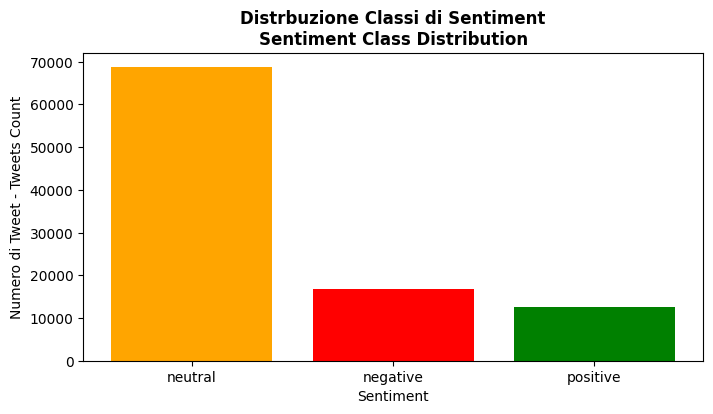

In [ ]:
# Visualizzazione grafica
# Chart view

# Conversione in Pandas
# Convert to Pandas
sentiment_dist_pd = df.groupBy("sentiment").count().orderBy("count", ascending=False).toPandas()

# Definizione colori standard per ciascuna classe
# Definetion of standard color for each class
COLOR_MAP = {"negative": "red", "neutral": "orange", "positive": "green"}

plt.figure(figsize=(8, 4))

plt.bar(sentiment_dist_pd["sentiment"], sentiment_dist_pd["count"],
        color=[COLOR_MAP[sentiment] for sentiment in sentiment_dist_pd["sentiment"]])

plt.title("Distrbuzione Classi di Sentiment\nSentiment Class Distribution", fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Numero di Tweet - Tweets Count")

plt.show()

**Commento**: L'analisi evidenzia una marcata predominanza della classe "neutral", che rappresenta la parte dei tweet analizzati. Tra le classi polarizzate si ossera una moderata prevalenza del sentiment negativo rispetto a quello positivo. La predominanza di un sentiment neutrale risulta coerente con la natura dei tweet relativi all'ambito finanziario e alle criptovalute, che spesso riguardano aggiornamenti di prezzo, notizie di mercato e contenuti informativi, piuttosto che espressioni esplicitamente emotive.

_**Comment**: The analysis highlights a marked predominance of neutral class, wich accounts for the majority of the nalyzed tweets. Among polarized classes, a moderate prevalence of negative sentiment over positive sentiment can be observed. The predominance of neutral sentiment is consistent with the nature of tweets related to the financial and cryptocurrency domain, which frequently consist of price updates, market news and informational content rather than explicity emotional expressions._

##**3. Variazione Temporale del Sentiment / _Temporal Variation of Sentiment_**

In [ ]:
# Aggregazione mensile dei tweet per classe
# Monthly aggregation of tweets by class
df_monthly = df.withColumn("year_month", to_date(date_trunc("month", col("date")))) \
                  .groupBy("year_month", "sentiment").count().orderBy("year_month")

# Costruzione tabella pivot: conteggio di ciascuna classe per ogni mese di ogni anno
# Pivot table construction: count of each class for each month of each year
pivot = df_monthly.groupBy("year_month").pivot("sentiment").sum("count").fillna(0).orderBy("year_month")


pivot.show()

+----------+--------+-------+--------+
|year_month|negative|neutral|positive|
+----------+--------+-------+--------+
|2009-01-01|       0|      1|       0|
|2012-08-01|       0|      1|       0|
|2012-09-01|       0|      1|       0|
|2012-11-01|       0|      0|       1|
|2013-08-01|       0|      1|       0|
|2013-12-01|       1|      2|       0|
|2014-02-01|       0|      1|       0|
|2014-07-01|       0|      1|       0|
|2014-08-01|       0|      1|       0|
|2014-10-01|       0|      1|       0|
|2014-12-01|       0|      1|       0|
|2015-02-01|       0|      1|       0|
|2015-09-01|       0|      1|       0|
|2015-10-01|       0|      1|       0|
|2015-11-01|       1|      0|       0|
|2016-02-01|       0|      1|       0|
|2016-03-01|       0|      3|       0|
|2016-05-01|       0|      6|       0|
|2016-06-01|       0|      6|       0|
|2016-07-01|       0|      1|       0|
+----------+--------+-------+--------+
only showing top 20 rows


Numero di tweet per classe e per anno
Number of tweets per class and per year
   year  negative  neutral  positive  total
0  2009         0        1         0      1
1  2012         0        2         1      3
2  2013         1        3         0      4
3  2014         0        5         0      5
4  2015         1        3         0      4
5  2016         2       23         2     27
6  2017         9       85         2     96
7  2018        29     1480        35   1544
8  2019     16713    67077     12476  96266


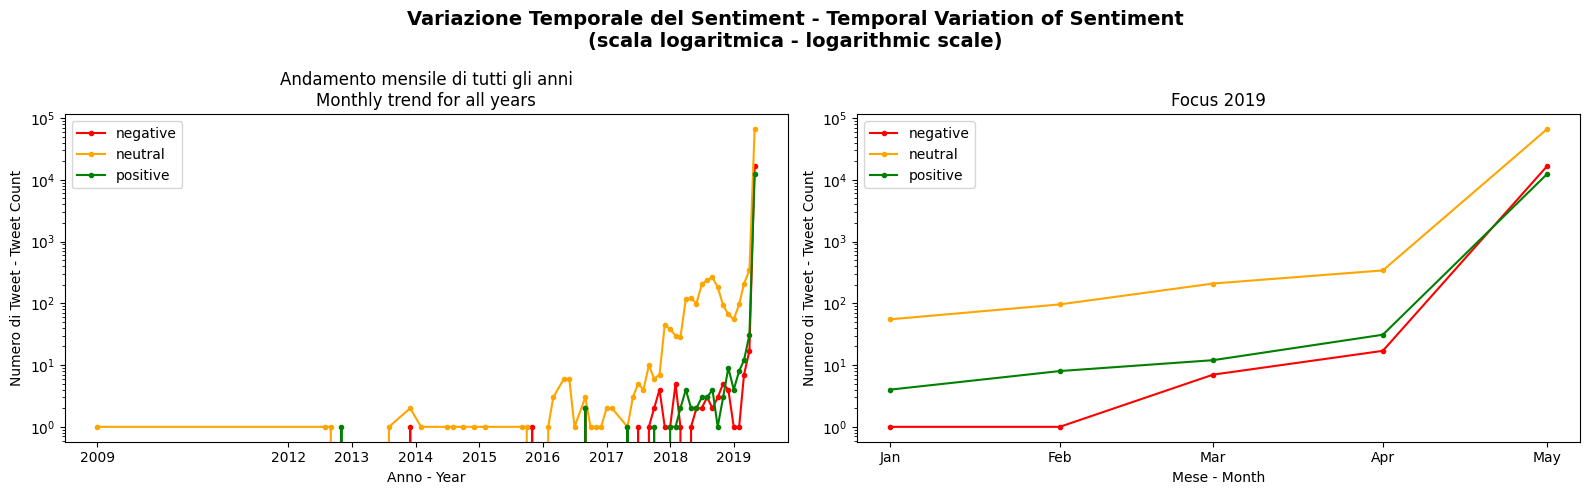

In [ ]:
# Conversione in Pandas della tabella pivot per il grafico
# Converting the pivot table for the chart to Pandas
pivot_pd = pivot.toPandas()

# Conversione in formato datetime
# Conversion to datetime format
pivot_pd["year_month"] = pd.to_datetime(pivot_pd["year_month"])

# Lista sentiment
# Sentiment list
sentiment_cols = ["negative", "neutral", "positive"]

# Tabella aggregata per anno: numero totale tweet per classe
# Yearly aggregated table: total number of tweets per class
print("Numero di tweet per classe e per anno\nNumber of tweets per class and per year")
yearly_agg = pivot_pd.assign(year=pivot_pd["year_month"].dt.year).groupby("year")[sentiment_cols].sum().reset_index()
yearly_agg["total"] = yearly_agg[sentiment_cols].sum(axis=1)
print(yearly_agg)

# Grafici variazione temporale del sentiment
# Charts of temporal variation of sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Variazione Temporale del Sentiment - Temporal Variation of Sentiment\n(scala logaritmica - logarithmic scale)",
             fontweight="bold", fontsize=14)

# Grafico 1: andamento mensile globale
# Chart 1: global monthly tred
years = sorted(pivot_pd["year_month"].dt.year.unique())
year_ticks = [str(year) for year in years]

for sentiment in sentiment_cols:
  axes[0].plot(pivot_pd["year_month"], pivot_pd[sentiment], label=sentiment,
               color=COLOR_MAP[sentiment], marker="o", markersize=3)

axes[0].set_title("Andamento mensile di tutti gli anni\nMonthly trend for all years")
axes[0].set_xlabel("Anno - Year")
axes[0].set_ylabel("Numero di Tweet - Tweet Count")
axes[0].set_yscale("log")
axes[0].set_xticks(year_ticks)
axes[0].set_xticklabels(years)
axes[0].legend()

# Grafico 2: focus sul 2019
# Chart 2: focus on 2019
pivot_2019 = pivot_pd[pivot_pd["year_month"].dt.year == 2019]
months = pivot_2019["year_month"]

for sentiment in sentiment_cols:
  axes[1].plot(pivot_2019["year_month"], pivot_2019[sentiment], label=sentiment,
               color=COLOR_MAP[sentiment], marker="o", markersize=3)

axes[1].set_title("Focus 2019")
axes[1].set_xlabel("Mese - Month")
axes[1].set_ylabel("Numero di Tweet - Tweet Count")
axes[1].set_yscale("log")
axes[1].set_xticks(months)
axes[1].set_xticklabels(months.dt.strftime("%b"))
axes[1].legend()

plt.tight_layout()
plt.show()

**Commento:** L'analisi temporale su scala logaritmica evidenzia una crescita di volume di tweet nel tempo, con un aumento significativo nel 2018 e un picco evidente nel 2019, che viene pertanto analizzato in un focus dedicato. Tale crescita può essere attribuita sia alla progressiva diffusione e utilizzo dei social media, sia al possibile aumento dell'interesse generale verso il Bitcoin in quel periodo.<br>
Nei primi anni osservati i volumi risultano molto contenuti e non si rileva una polarità dominante stabile: l'alternanza tra sentiment positivo e negativo varia di anno in anno, con differenze contenute rispetto al totale di tweet.<br>
Nel 2017 si osserva una lieve prevalenza del sentiment negativo, mentre nel 2018, complessivamente, emerge una leggera predominanza di quello positivo.<br>
Nel focus sul 2019 il sentiment appare inizialmente più orientato verso la classe positiva; tuttavia, nel corso dei mesi si registra un incremento costante della classe negativa, che tende progressivamente a ridurre il divario fino a superare quella positiva nella fase finale del periodo osservato.<br>
In tutto il periodo osservato si conferma in ogni caso la predominanza della classe neutrale.<br>
**Nota:** Nel grafico globale sono riportati sull'asse esclusivamente gli anni presenti all'interno del dataset.

_**Comment:** The temporal analysis on a logarithmic scale highlights a progressive increase in tweet volume over time, with a significant rise in 2018 and a clear peak in 2019, which is therefore examined through a dedicated focus. This growth may be attributed both to the progressive diffusion and use of social media and to a possible increase in general interest in Bitcoin during that period.<br>
In the early observed years, volumes remain very limited and no stable dominant polarity emerges: the alternation between positive and negative sentiment varies from year to year, with relatively small differences compared to the overall tweet volume.<br>
In 2017, a slight prevalence of negative sentiment is observed, while in 2018 a moderate predominance of positive sentiment emerges.<br>
In the 2019 focus, sentiment initially appears more oriented toward the positive class; however, over the months a steady increase in the negative class is observed, that gradually tends to reduce the gap until it exceeds the positive class in the final pahse of the period considered.<br>
Across the entire observed period, the neutral class remains predominant in absolute terms.<br>
**Note:** In the global chart, only the years present in the dataset are displayed on the axis._

##**4. Analisi delle Interazioni / _Engagement Analysis_**

**Analisi Comparativa dei Like tra Tweet Negativi e Positivi<br>
_Comparative Analysis of Likes Between Negative and Positive Tweets_**


In [ ]:
# Filtro su sentiment positivo e negativo
# Filter on positive and negative sentiment
df_neg_pos = df.filter((df.sentiment.isin("negative", "positive"))).orderBy("sentiment")

# Media dei like
# Likes average
avg_likes = df_neg_pos.groupBy("sentiment").agg(round(avg("likes"), 2).alias("avg_likes"))
avg_likes.show()

+---------+---------+
|sentiment|avg_likes|
+---------+---------+
| negative|    11.57|
| positive|     9.56|
+---------+---------+



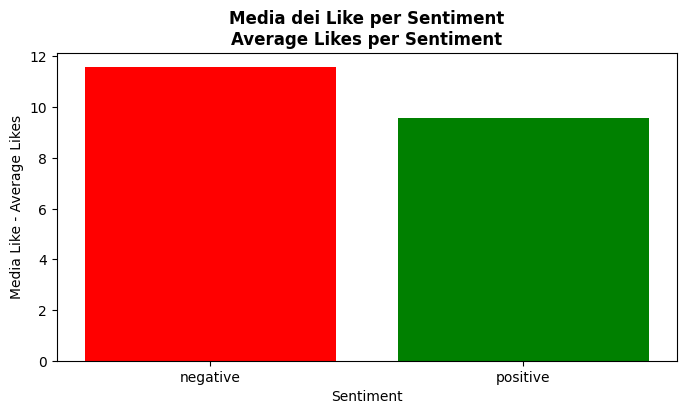

In [ ]:
# Conversione in DF Pandas per grafico
# Convert to Pandas DF for chart
avg_likes_pd = avg_likes.toPandas()

# Grafico a barre
# Bar chart
plt.figure(figsize=(8, 4))

plt.bar(avg_likes_pd["sentiment"], avg_likes_pd["avg_likes"], color=["red", "green"])

plt.title("Media dei Like per Sentiment\nAverage Likes per Sentiment", fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Media Like - Average Likes")

plt.show()

**Commento:** L'analisi comparativa delle medie mostra che i tweet con tono negativo ricevono, in media, un numero di like leggermente superiore rispetto ai tweet positivi. Pertanto, in base ai dati analizzati, si può affermare che i tweet negativi attirano maggiore attenzione e interesse ripsetto a quelli positivi.

_**Comment:** The comparative analysis of the averages shows that the tweets with a negative tone receive, on average, a slightly higher number of likes compared to positive tweets. Therefor, based ono the analyzed data, it can be stated that negative tweets attract greater attention and interest than posives ones._

**Analisi Comparativa delle Risposte tra Tweet Negativi e Positivi<br>
_Comparative Analysis of Replies Between Negative and Positive Tweets_**

In [ ]:
# Media delle risposte
# Replies average
avg_replies = df_neg_pos.groupBy("sentiment").agg(round(avg("replies"), 2).alias("avg_replies"))
avg_replies.show()

+---------+-----------+
|sentiment|avg_replies|
+---------+-----------+
| negative|       1.09|
| positive|       0.79|
+---------+-----------+



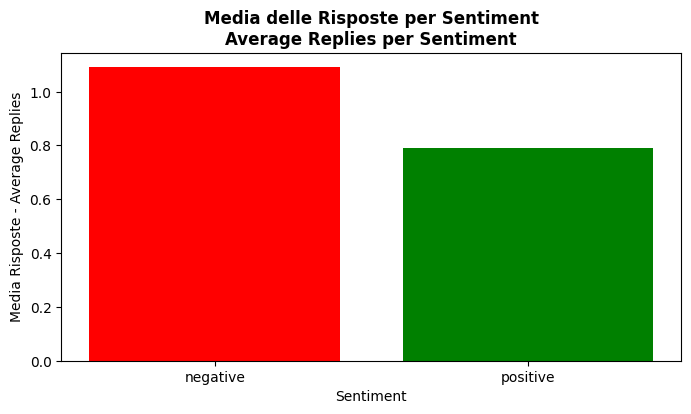

In [ ]:
# Conversione in DF Pandas per grafico
# Convert to Pandas DF for chart
avg_replies_pd = avg_replies.toPandas()

# Grafico a barre
# Bar chart
plt.figure(figsize=(8, 4))

plt.bar(avg_replies_pd["sentiment"], avg_replies_pd["avg_replies"], color=["red", "green"])

plt.title("Media delle Risposte per Sentiment\nAverage Replies per Sentiment", fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Media Risposte - Average Replies")

plt.show()

**Commento:** L'analisi comparativa delle medie indica che i tweet con tono negativo generano, in media, un numero di risposte superiore rispetto ai tweet positivi. Pur non trattandosi di uno scarto particolamente ampio in termini assoluti, sulla base dei dati analizzati, il sentiment negativo sembra stimolare una discussione più intensa.

_**Comment:** The comparative analysis of averages indicates that tweets with negative sentiment generate, on average, a higher number of riplies compared to positive tweets. Although the difference is not particulary large in absolute terms, based on the analyzed data, negative sentiment appears to stimulate a more intense discussion._

##**5. Relazione tra Sentiment e Valore del Bitcoin /<br>_Realtionship Between Sentiment and Bitcoin Price_**

**Preparazione Dataset Bitcoin / _Bitcoin Dataset Preparation_**

In [ ]:
# Caricamento dataset in DF Spark
# Load dataset in Spark DF
URL = "https://raw.githubusercontent.com/Profession-AI/progetti-big-data/refs/heads/main/Analisi%20del%20consenso%20sul%20Bitcoin/BTC-USD.csv"
LOCAL_PATH = "/content/BTC-USD.csv"

! wget -O {LOCAL_PATH} "{URL}"

df_btc = spark.read.csv(LOCAL_PATH, header=True, inferSchema=True, multiLine=True, escape='"')

# Ispezione iniziale del df
# Initial inspection of df
print("Records:", df_btc.count())
df_btc.printSchema()
df_btc.show(15, False)

--2026-03-02 18:26:21--  https://raw.githubusercontent.com/Profession-AI/progetti-big-data/refs/heads/main/Analisi%20del%20consenso%20sul%20Bitcoin/BTC-USD.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 423556 (414K) [text/plain]
Saving to: ‘/content/BTC-USD.csv’

/content/BTC-USD.cs 100%[===================>] 413.63K  --.-KB/s    in 0.02s   

2026-03-02 18:26:21 (17.0 MB/s) - ‘/content/BTC-USD.csv’ saved [423556/423556]

Records: 3930
root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)

+------------

In [ ]:
# Selezione delle sole colonne necessarie
# Selecting only the necessary columns
df_btc = df_btc.select(to_date("Date").alias("date"),
                       col("Close").alias("close_price"))

df_btc.printSchema()
df_btc.show(15, False)

root
 |-- date: date (nullable = true)
 |-- close_price: double (nullable = true)

+----------+------------------+
|date      |close_price       |
+----------+------------------+
|2014-09-17|457.3340148925781 |
|2014-09-18|424.44000244140625|
|2014-09-19|394.7959899902344 |
|2014-09-20|408.90399169921875|
|2014-09-21|398.8210144042969 |
|2014-09-22|402.1520080566406 |
|2014-09-23|435.7909851074219 |
|2014-09-24|423.2049865722656 |
|2014-09-25|411.5740051269531 |
|2014-09-26|404.42498779296875|
|2014-09-27|399.5199890136719 |
|2014-09-28|377.1809997558594 |
|2014-09-29|375.4670104980469 |
|2014-09-30|386.9440002441406 |
|2014-10-01|383.614990234375  |
+----------+------------------+
only showing top 15 rows


In [ ]:
# Finestra ordinata per data
# Window order by date
window = Window.orderBy("date")

# Prezzo giorno precedente
# Previous day's price
df_btc = df_btc.withColumn("prev_close", lag("close_price").over(window))

# Calcolo percentuale variazione prezzo
# Percentage price change calculation
df_btc = df_btc.withColumn("price_change(%)",
              round((col("close_price") - col("prev_close")) / col("prev_close") * 100, 2))

df_btc.show()

+----------+------------------+------------------+---------------+
|      date|       close_price|        prev_close|price_change(%)|
+----------+------------------+------------------+---------------+
|2014-09-17| 457.3340148925781|              NULL|           NULL|
|2014-09-18|424.44000244140625| 457.3340148925781|          -7.19|
|2014-09-19| 394.7959899902344|424.44000244140625|          -6.98|
|2014-09-20|408.90399169921875| 394.7959899902344|           3.57|
|2014-09-21| 398.8210144042969|408.90399169921875|          -2.47|
|2014-09-22| 402.1520080566406| 398.8210144042969|           0.84|
|2014-09-23| 435.7909851074219| 402.1520080566406|           8.36|
|2014-09-24| 423.2049865722656| 435.7909851074219|          -2.89|
|2014-09-25| 411.5740051269531| 423.2049865722656|          -2.75|
|2014-09-26|404.42498779296875| 411.5740051269531|          -1.74|
|2014-09-27| 399.5199890136719|404.42498779296875|          -1.21|
|2014-09-28| 377.1809997558594| 399.5199890136719|          -5

**Preparazione Dataset dei Tweet / _Tweets Dataset Preparation_**

In [ ]:
# Selezione colonne necessarie da df già filtrato solo per classi "negative" e "positive" e aggregazione giornaliera
# Select necessary columns from df already filtered only for "negative" and "positive" classes and daily aggregation
df_tweets = df_neg_pos.select("date", "sentiment").groupBy("date", "sentiment").count()

# Pivot per ottenere colonne delle due classi separate
# Pivot to obtain separate cloumns for the two classes
df_tweets = df_tweets.groupBy("date").pivot("sentiment").sum("count").fillna(0).orderBy("date")

df_tweets.printSchema()
df_tweets.show()

root
 |-- date: date (nullable = true)
 |-- negative: long (nullable = true)
 |-- positive: long (nullable = true)

+----------+--------+--------+
|      date|negative|positive|
+----------+--------+--------+
|2012-11-17|       0|       1|
|2013-12-19|       1|       0|
|2015-11-19|       1|       0|
|2016-09-26|       2|       0|
|2016-09-29|       0|       2|
|2017-05-24|       0|       1|
|2017-07-28|       1|       0|
|2017-09-14|       1|       0|
|2017-10-16|       0|       1|
|2017-10-19|       1|       0|
|2017-10-21|       1|       0|
|2017-11-09|       1|       0|
|2017-11-29|       3|       0|
|2017-12-07|       1|       0|
|2018-01-01|       0|       1|
|2018-01-22|       1|       0|
|2018-02-08|       1|       0|
|2018-02-15|       2|       0|
|2018-02-18|       1|       0|
|2018-02-20|       1|       0|
+----------+--------+--------+
only showing top 20 rows


**Allineamento Temporale dei Due Dataset /_Temporal Alignment of the Two Datasets_**

In [ ]:
# Visualizzazione data minima e massima dei due df (per i tweet si prende in considerazione l'intero dataset)
# Max and min date display for the two df (for tweets, the entire dataset is taken into cosideration)
btc_range = df_btc.select(min("date").alias("btc_min"), max("date").alias("btc_max"))
tweet_range = df.select(min("date").alias("tweet_min"), max("date").alias("tweet_max"))

btc_range.show()
tweet_range.show()

+----------+----------+
|   btc_min|   btc_max|
+----------+----------+
|2014-09-17|2025-06-20|
+----------+----------+

+----------+----------+
| tweet_min| tweet_max|
+----------+----------+
|2009-01-11|2019-05-27|
+----------+----------+



In [ ]:
# Filtraggio BTC per range temporale comune
# Filter BTC for common date range
df_btc = df_btc.filter((col("date") >= "2014-09-17") & (col("date") <= "2019-05-27"))

# Join BTC con Tweets mantendendo serie temporale giornaliera
# Join BTC with Tweets while maintaining daily time series
df_join = df_btc.join(df_tweets, on="date", how="left").fillna(
    0, subset=["negative", "positive"]).orderBy("date")

# Rimozione colonna prev_close non più necessaria
# Drop prev_close column no longer necessary
df_join = df_join.drop("prev_close")

print("Records:", df_join.count(), "giorni - days")
df_join.printSchema()
df_join.show()

Records: 1714 giorni - days
root
 |-- date: date (nullable = true)
 |-- close_price: double (nullable = true)
 |-- price_change(%): double (nullable = true)
 |-- negative: long (nullable = true)
 |-- positive: long (nullable = true)

+----------+------------------+---------------+--------+--------+
|      date|       close_price|price_change(%)|negative|positive|
+----------+------------------+---------------+--------+--------+
|2014-09-17| 457.3340148925781|           NULL|       0|       0|
|2014-09-18|424.44000244140625|          -7.19|       0|       0|
|2014-09-19| 394.7959899902344|          -6.98|       0|       0|
|2014-09-20|408.90399169921875|           3.57|       0|       0|
|2014-09-21| 398.8210144042969|          -2.47|       0|       0|
|2014-09-22| 402.1520080566406|           0.84|       0|       0|
|2014-09-23| 435.7909851074219|           8.36|       0|       0|
|2014-09-24| 423.2049865722656|          -2.89|       0|       0|
|2014-09-25| 411.5740051269531|         

**Costruzione Indicatore Discreto del Sentiment /_Build Discrete Sentiment Indicator_**

Se in quella data:
- tweet negativi > tweet positivi -> indicatore = -1
- assenza o parità di tweet negativi e positivi -> indicatore = 0
- tweet positivi > tweet negativi -> indicatore = 1

_For each date, if:_
- _negative tweets > positive tweets -> indicator = -1_
- _absence or equal number of negative and positive tweets -> indicator = 0_
- _positive tweets > negative tweets -> indicator = 1_

In [ ]:
# Costruzione indicatore
# Buil indicator
df_join = df_join.withColumn("sentiment_indicator",
              when(col("positive") > col("negative"), 1) \
              .when(col("positive") < col("negative"), -1) \
              .otherwise(0))

# Visualizzazione filtrata per verificare che il calcolo di -1 e 1 sia stato eseguito correttamente
# Filtered view to verify that the calculation of -1 and 1 has been performed correctly
df_join.filter((col("negative") > 0) | (col("positive") > 0)).show()

+----------+------------------+---------------+--------+--------+-------------------+
|      date|       close_price|price_change(%)|negative|positive|sentiment_indicator|
+----------+------------------+---------------+--------+--------+-------------------+
|2015-11-19|326.14898681640625|          -2.52|       1|       0|                 -1|
|2016-09-26| 608.0430297851562|            1.2|       2|       0|                 -1|
|2016-09-29| 605.6929931640625|           0.16|       0|       2|                  1|
|2017-05-24| 2443.639892578125|           5.31|       0|       1|                  1|
|2017-07-28| 2809.010009765625|           5.14|       1|       0|                 -1|
|2017-09-14| 3154.949951171875|         -18.74|       1|       0|                 -1|
|2017-10-16|     5725.58984375|           0.83|       0|       1|                  1|
|2017-10-19|  5708.52001953125|           2.11|       1|       0|                 -1|
|2017-10-21|  6031.60009765625|           0.34|       

**Analisi di Correlazione: Prezzo Bitcoin vs Sentiment / _Correlation Analysis: Bitcoin Price vs Sentiment_**

- Utilizzando indicatore discreto del sentiment / _Using a discrete sentiment indicator_

In [ ]:
# Creazione delle versioni shiftate (t-1 e t+1) della colonna price_change(%) per analisi temporale
# Creation of shifted version (t-1 and t+1) of the price_change(%) column for temporal analysis
df_corr = df_join.withColumn("price_change_prev", lag("price_change(%)", 1).over(window)) \
                .withColumn("price_change_next", lead("price_change(%)", 1).over(window))

# Calcolo correlazioni
# Carrelation calculation
corr_same_day = df_corr.stat.corr("sentiment_indicator", "price_change(%)")

corr_prev_day = df_corr.stat.corr("sentiment_indicator", "price_change_prev")

corr_next_day = df_corr.stat.corr("sentiment_indicator", "price_change_next")

print("Correlazione stesso giorno - Same day correlation:", corr_same_day)
print("Correlazione giorno precedente - Previous day correlation:", corr_prev_day)
print("Correlazione giorno successivo - Next day correlation:", corr_next_day)

Correlazione stesso giorno - Same day correlation: 0.006197425615974912
Correlazione giorno precedente - Previous day correlation: -0.018850428893390746
Correlazione giorno successivo - Next day correlation: -0.010763896788384441


- Utilizzando separatamente le due classi / _Using the two individual sentiment classes_

In [ ]:
# Calcolo correlazioni singole classi
# Carrelation calculation individual classes
corr_same_day_neg = df_corr.stat.corr("negative", "price_change(%)")
corr_same_day_pos = df_corr.stat.corr("positive", "price_change(%)")

corr_prev_day_neg = df_corr.stat.corr("negative", "price_change_prev")
corr_prev_day_pos = df_corr.stat.corr("positive", "price_change_prev")

corr_next_day_neg = df_corr.stat.corr("negative", "price_change_next")
corr_next_day_pos = df_corr.stat.corr("positive", "price_change_next")

print(f"Correlazione stesso giorno - Same day correlation\nSentiment Negativo - Negative: {corr_same_day_neg}\n"+
      f"Sentiment Positivo - Positive: {corr_same_day_pos}")
print("=========================================================================")
print(f"Correlazione giorno precedente - Previous day correlation\nSentiment Negativo - Negative: {corr_prev_day_neg}\n"+
      f"Sentiment Positivo - Positive: {corr_prev_day_pos}")
print("=========================================================================")
print(f"Correlazione giorno successivo - Next day correlation\nSentiment Negativo - Negative: {corr_next_day_neg}\n"+
      f"Sentiment Positivo - Positive: {corr_next_day_pos}")

Correlazione stesso giorno - Same day correlation
Sentiment Negativo - Negative: 0.06756132767548709
Sentiment Positivo - Positive: 0.07184768401337953
Correlazione giorno precedente - Previous day correlation
Sentiment Negativo - Negative: 0.029309920268097436
Sentiment Positivo - Positive: 0.029957234918202742
Correlazione giorno successivo - Next day correlation
Sentiment Negativo - Negative: 0.0457441758237442
Sentiment Positivo - Positive: 0.039054815502136415


**Commento:** L'analisi di correlazione tra l'indicatore discreto del sentiment (-1, 0, 1) e la variazione percentuale giornaliera del prezzo del Bitcoin mostra valori prossimi allo zero sia per lo stesso giorno, sia considerando uno scarto temporale di un giorno precedente e un giorno successivo.<br>
La medesima evidenza emerge anche dall'analisi condotta separatamente sulle singole classi di sentiment (negativo e positivo), i cui coefficienti di correlazione risultano anch'essi prossimi allo zero in tutti i casi considerati.<br>
Nel complesso, entrambe le modalità di calcolo conducono alla stessa conclusione: sulla base ai dati analizzati, non emergono evidenze statistiche che indichino che il sentiment pubblico influenzi il prezzo del Bitcoin, né che le variazioni di prezzo della criptovaluta determinino un cambiamento del sentiment nel giorno precedente o successivo.

_**Comment:** The correlation analysis between the discrete sentiment indicator (-1, 0, 1) and the daily percentage change in Bitcoin price show values close to zero both for same day and when considering a one-day lag (prevoius day) and one-day lead (next day).<br>
The same evidence also emerges from the analysis conducted separately on the individual sentiment classes (negative and positive), whose correlation coefficients likewise result close to zero in all the consideraded cases.<br>
Overall, both calculation approaches lead to the same conclusion: based on the analyzed data, there is no statistical evidence indicating that public sentiment influences the price of Bitcoin, nor that price variations of the cryptocurrency determine a change in sentiment on the previous or following day._

**Analisi di Correlazione: Prezzo Bitcoin vs Sentiment / _Correlation Analysis: Bitcoin Price vs Sentiment_<br>
Focus 2019**

- Utilizzando indicatore discreto del sentiment / _Using a discrete sentiment indicator_

In [ ]:
# Filtro su anno 2019
# Filter by year 2019
df_corr_2019 = df_corr.filter(year("date") == 2019)

# Calcolo correlazioni
# Carrelation calculation
corr_same_day_2019 = df_corr_2019.stat.corr("sentiment_indicator", "price_change(%)")

corr_prev_day_2019 = df_corr_2019.stat.corr("sentiment_indicator", "price_change_prev")

corr_next_day_2019 = df_corr_2019.stat.corr("sentiment_indicator", "price_change_next")

print("Focus 2019")
print("Correlazione stesso giorno - Same day correlation:", corr_same_day_2019)
print("Correlazione giorno precedente - Previous day correlation:", corr_prev_day_2019)
print("Correlazione giorno successivo - Next day correlation:", corr_next_day_2019)

Focus 2019
Correlazione stesso giorno - Same day correlation: -0.08511040461991691
Correlazione giorno precedente - Previous day correlation: -0.021575514175080447
Correlazione giorno successivo - Next day correlation: 0.027987644531269604


- Utilizzando separatamente le due classi / _Using the two individual sentiment classes_

In [ ]:
# Calcolo correlazioni singole classi
# Carrelation calculation individual classes
corr_same_day_neg_2019 = df_corr_2019.stat.corr("negative", "price_change(%)")
corr_same_day_pos_2019 = df_corr_2019.stat.corr("positive", "price_change(%)")

corr_prev_day_neg_2019 = df_corr_2019.stat.corr("negative", "price_change_prev")
corr_prev_day_pos_2019 = df_corr_2019.stat.corr("positive", "price_change_prev")

corr_next_day_neg_2019 = df_corr_2019.stat.corr("negative", "price_change_next")
corr_next_day_pos_2019 = df_corr_2019.stat.corr("positive", "price_change_next")

print("Focus 2019")
print("=========================================================================")
print(f"Correlazione stesso giorno - Same day correlation\nSentiment Negativo - Negative: {corr_same_day_neg_2019}\n"+
      f"Sentiment Positivo - Positive: {corr_same_day_pos_2019}")
print("=========================================================================")
print(f"Correlazione giorno precedente - Previous day correlation\nSentiment Negativo - Negative: {corr_prev_day_neg_2019}\n"+
      f"Sentiment Positivo - Positive: {corr_prev_day_pos_2019}")
print("=========================================================================")
print(f"Correlazione giorno successivo - Next day correlation\nSentiment Negativo - Negative: {corr_next_day_neg_2019}\n"+
      f"Sentiment Positivo - Positive: {corr_next_day_pos_2019}")

Focus 2019
Correlazione stesso giorno - Same day correlation
Sentiment Negativo - Negative: 0.26505663880379954
Sentiment Positivo - Positive: 0.2826027558392696
Correlazione giorno precedente - Previous day correlation
Sentiment Negativo - Negative: 0.10728637696446848
Sentiment Positivo - Positive: 0.10987127781848186
Correlazione giorno successivo - Next day correlation
Sentiment Negativo - Negative: 0.17574471824659146
Sentiment Positivo - Positive: 0.14794009478562534


**Commento:** Anche nel focus sul 2019 l'analisi di correlazione tra l'indicatore discreto del sentiment (-1, 0, 1) e la variazione percentuale giornaliera del prezzo del Bitcoin mostra valori prossimi allo zero sia per lo stesso giorno, sia considerando uno scarto temporale di un giorno precedente e un giorno successivo.<br>
L'analisi condotta sulle singole classi separate, invece, mostra un risultato leggermente diverso, con valori di correlazione positiva moderatamente più alti, specialmente per lo stesso giorno (negativa: circa 0.27 - positiva: 0.28), seppur di entità ancora molto contenuta.<br>
Nel complesso, pur emergendo una debole associazione tra volumi di tweet e variazione di prezzo nel 2019, quando si considerano le classi separate, l'intensità delle correlazioni rimane moderata, non consentendo di inferire un rapporto causale tra il sentiment pubblico e la variazione di prezzo del Bitcoin.

_**Comment:** Also in the focus 2019, the correlation analysis between the discrete sentiment indicator (-1, 0, 1) and the daily percentage change in Bitcoin price show values close to zero both for same day and when considering a one-day lag (prevoius day) and one-day lead (next day).<br>
However, the analysis conducted separately classes shows a slightly different result, with modarate higher positive correlation values, especially fro the same day (negative approximately 0.27 - positive: 0.28), although still of very limited magnitude.<br>
Overall, although a weak association between tweets volumes and price variation emerges in 2019 when considering the classes separately, the intensity of the correlations remains moderates and does not allow for inferring a causal relationship between public sentiment and Bitcoin price variation._

##**6. Conclusioni / _Conclusions_**

**ITA**

L’analisi condotta ha previsto una fase di preprocessing testuale e classificazione automatica del sentiment tramite modello pretrained, seguita dall’integrazione con dati finanziari e da analisi descrittive e statistiche finalizzate ad esplorare la relazione tra consenso espresso su Twitter e variazioni del prezzo del Bitcoin.

La distribuzione temporale dei tweet evidenzia una crescita significativa dei volumi nel tempo, con un picco nel 2019, anno in cui l’attività online ha iniziato ad essere particolarmente più intensa.<br>
L’analisi del sentiment mostra un’alternanza tra componenti positive e negative, con una costante predominanza della classe neutrale nell'intero periodo osservato.<br>
Dal punto di vista dell’interazione, i tweet con sentiment negativo generano in media un numero di risposte leggermente superiore rispetto a quelli positivi, suggerendo una maggiore capacità di stimolare discussione, pur in presenza di differenze contenute.

L’analisi di correlazione tra sentiment e variazione percentuale del prezzo del Bitcoin, sia sull’intero periodo sia nel focus sul 2019, non evidenzia relazioni lineari significative quando si utilizza l’indicatore discreto aggregato. Considerando separatamente le classi di sentiment, emerge nel 2019 una debole associazione positiva; tuttavia, l’intensità delle correlazioni rimane moderata e non consente di inferire un rapporto causale tra dinamiche di prezzo e sentiment pubblico.

Nel complesso, i risultati suggeriscono che il sentiment espresso sui social media, nel periodo analizzato, non costituisce un indicatore lineare robusto delle dinamiche giornaliere del prezzo del Bitcoin.


_**ENG**_

_The conducted analysis included a text preprocessing phase and automatic sentiment classification using a pretrained model, followed by integration with financial data and descriptive and statistical analyses aimed at exploring the relationship between consensus expressed on Twitter and variations in Bitcoin price._

_The temporal distribution of tweets shows a significant growth in volumes over time, with a peak in 2019, a year in which online activity began to become particularly intense.<br>
The sentiment analysis reveals an alternation between positive and negative components, with a consistent predominance of the neutral class throughout the entire observed period.<br>
From an interaction perspective, tweets with negative sentiment generate, on average, a slightly higher number of replies compared to positive ones, suggesting a greater ability to stimulate discussion, albeit in the presence of limited differences._

_The correlation analysis between sentiment and the daily percentage change in Bitcoin price, both over the entire period and in the focus on 2019, does not reveal significant linear relationships when using the aggregated discrete indicator. When considering the sentiment classes separately, a weak positive association emerges in 2019; however, the intensity of the correlations remains moderate and does not allow for inferring a causal relationship between price dynamics and public sentiment._

_Overall, the results suggest that sentiment expressed on social media, in the analyzed period, does not constitute a robust linear indicator of daily Bitcoin price dynamics._